
## 1. Basic Text Pre-processing



Environment: Python 3.11.7 and Jupyter notebook

## Introduction
This assessment task involves performing text preprocessing on a dataset of clothing reviews. The primary focus is on cleaning and preparing the review text to create a structured representation of the data for subsequent analysis. The preprocessing steps include tokenization, converting words to lowercase, removing short words (less than 2 characters), and filtering out irrelevant or common words using a predefined stopword list. Additionally, infrequent words (those appearing only once) and the top 20 most frequent words are removed to reduce noise in the data. The cleaned reviews are stored alongside the original text, and a vocabulary of unique words is generated. This processed data is crucial for further tasks like feature extraction and model building in later stages of the assessment. 


## Importing libraries 

In [1]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import re
import numpy as np
from itertools import chain
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 Examining and loading data
This phase provides a comprehensive approach to examining and preparing the dataset for further analysis. It begins by loading the data into a pandas DataFrame and performing an initial inspection of the dataset's structure, including the shape, column names, data types, and missing values. Additionally, the code prints out the first and last few rows to give a snapshot of the data, helping to identify potential issues or areas that require cleaning. It also specifically focuses on the "Review Text" column, converting the text to lowercase to standardize it for future processing. Moreover, summary statistics are generated for numerical columns to understand the overall distribution of the data. This foundational exploration ensures that the data is clean and standardized.

In [ ]:
# Code to inspect the provided data file...
df = pd.read_csv('data.csv')
# Examine the data
print("Data Shape:", df.shape)
print("Data Columns:", df.columns)
print("Data Types:\n", df.dtypes)

Data Shape: (19662, 10)
Data Columns: Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')
Data Types:
 Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object


In [3]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


In [4]:
print("Data Head:\n")
df.head()

Data Head:



,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits


In [5]:
# Get the review text data
review_text = df['Review Text']

# Print the first few review texts
print("First few review texts:")
for i in range(5):
    print(review_text[i])

First few review texts:
I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c
I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!
This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!
I love tracy reese dresses, but this one is not for the very petite. i am just under 5 feet tall and usually wear a 0p in this brand. this dress was very pre

In [6]:
# Convert the review text to lowercase
review_text = review_text.str.lower()

# Print the first few review texts after converting to lowercase
print("First few review texts after converting to lowercase:")
for i in range(2):
    print(review_text[i])

First few review texts after converting to lowercase:
i had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c
i love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!


In [7]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,19662.000000,19662.000000,19662.000000,19662.000000,19662.000000
mean,921.297274,43.260808,4.183145,0.818177,2.652477
std,200.227528,12.258122,1.112224,0.385708,5.834285
min,1.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


### 1.2 Pre-processing data
This phase focuses on preprocessing the review text to clean and prepare it for further analysis. It starts by loading a list of stopwords and then applies tokenization to split the text into individual words. Each word is converted to lowercase, and short words or stopwords are removed to reduce noise. Additionally, words that appear only once across all reviews, as well as the top 20 most frequent words, are filtered out to ensure the focus is on more relevant and informative terms. After preprocessing, the code computes various statistics on the cleaned reviews, such as vocabulary size, token counts, and review lengths. These insights are visualized through histograms, pie charts, and bar plots, providing a clear view of the distribution of the processed data.

In [8]:
# Load stopwords
with open('stopwords_en.txt', 'r') as file:
    stopwords = set(file.read().split())

# Regular expression for tokenization
tokenizer_re = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"

# Preprocess each review using the provided function
def preprocess_review(review_text, stopwords):
    # 1. Tokenize the review text using the provided regex
    tokens = re.findall(tokenizer_re, review_text)
    
    # 2. Convert to lowercase
    tokens = [token.lower() for token in tokens]
    
    # 3. Remove words with length < 2
    tokens = [token for token in tokens if len(token) > 1]
    
    # 4. Remove stopwords
    tokens = [token for token in tokens if token not in stopwords]
    
    return tokens

# Apply preprocessing to "Review Text"
df['Processed_Review'] = df['Review Text'].apply(lambda x: preprocess_review(str(x), stopwords))

# Combine all tokens to find frequency
all_tokens = [token for sublist in df['Processed_Review'] for token in sublist]
token_counts = Counter(all_tokens)

# 5. Remove words that appear only once
df['Processed_Review'] = df['Processed_Review'].apply(lambda tokens: [token for token in tokens if token_counts[token] > 1])

# 6. Remove top 20 most frequent words
top_20_words = [word for word, _ in token_counts.most_common(20)]
df['Processed_Review'] = df['Processed_Review'].apply(lambda tokens: [token for token in tokens if token not in top_20_words])

# Convert lists of tokens back to strings for saving
df['Processed_Review'] = df['Processed_Review'].apply(lambda tokens: ' '.join(tokens))

# Function to compute statistics and visualize
def stats_print(tk_reviews):
    words = list(chain.from_iterable([review.split() for review in tk_reviews]))  # All tokens in a single list
    vocab = set(words)  # Unique vocabulary
    lexical_diversity = len(vocab) / len(words)
    
    print("Vocabulary size: ", len(vocab))
    print("Total number of tokens: ", len(words))
    print("Lexical diversity: ", lexical_diversity)
    print("Total number of reviews:", len(tk_reviews))
    
    lens = [len(review.split()) for review in tk_reviews]
    
    print("Average review length:", np.mean(lens))
    print("Maximum review length:", np.max(lens))
    print("Minimum review length:", np.min(lens))
    print("Standard deviation of review length:", np.std(lens))
    
    # Visualize review lengths
    plt.figure(figsize=(10, 6))
    sns.histplot(lens, bins=20, kde=True)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Review Length')
    plt.ylabel('Frequency')
    plt.show()

    # Visualize vocabulary size and total number of tokens
    labels = ['Vocabulary Size', 'Total Tokens']
    sizes = [len(vocab), len(words)]
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
    plt.title('Vocabulary Size vs. Total Tokens')
    plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
    plt.show()

    # Visualize most frequent words
    word_freq = Counter(words).most_common(20)
    word_freq_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Word', y='Frequency', data=word_freq_df, palette="viridis")
    plt.xticks(rotation=45)
    plt.title('Top 20 Most Frequent Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.show()



Vocabulary size:  7529
Total number of tokens:  355464
Lexical diversity:  0.021180766547385953
Total number of reviews: 19662
Average review length: 18.07873054623131
Maximum review length: 47
Minimum review length: 0
Standard deviation of review length: 8.789500621976579


c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


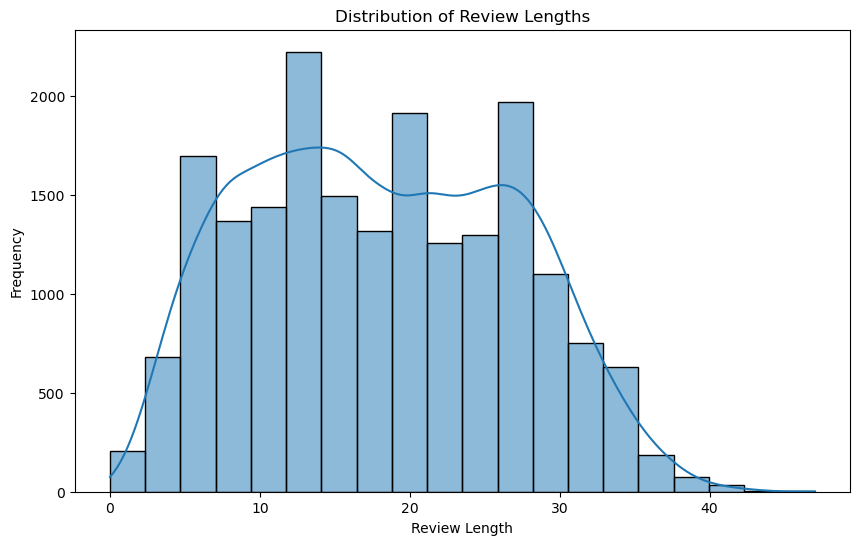

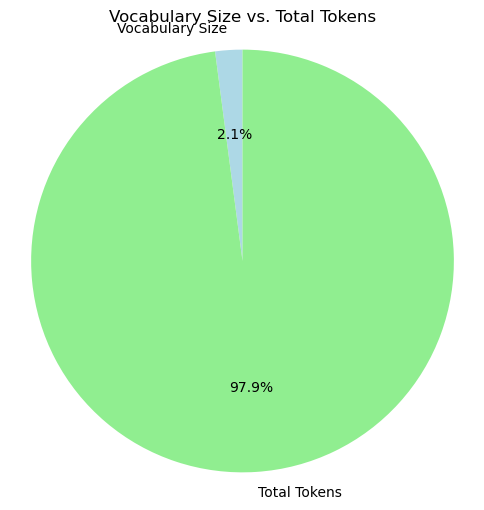

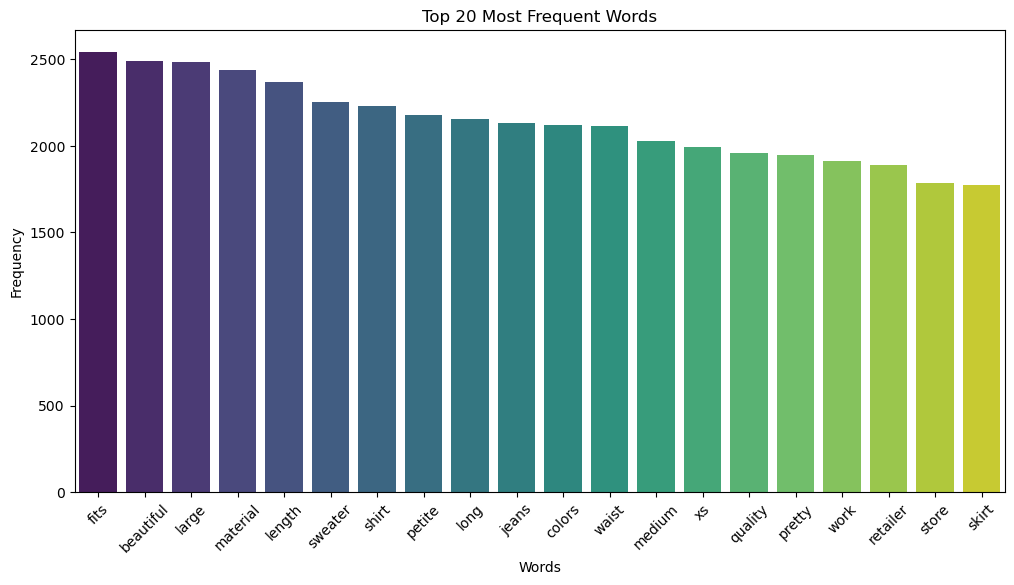

In [9]:
# Analyze the tokenized reviews
tokenized_reviews = df['Processed_Review'].tolist()
stats_print(tokenized_reviews)


In [10]:
#check if the processed data has null values
print("Missing Values in Processed Data:\n", df.isnull().sum())

Missing Values in Processed Data:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Processed_Review           0
dtype: int64


## Saving required outputs
The cleaned text data is then saved to a CSV file, and a vocabulary list is generated, where each word is assigned a unique index, allowing for easy reference in future tasks.
- vocab.txt

In [11]:
# code to save output data...
# Save processed data with the original data included
# df.to_csv('processed.csv', index=False)
df.dropna().to_csv('processed.csv', index=False)

# 7. Build the vocabulary and save to a txt file in the required format
vocabulary = sorted(set([token for sublist in df['Processed_Review'].str.split() for token in sublist]))

with open('vocab.txt', 'w') as vocab_file:
    for idx, word in enumerate(vocabulary):
        vocab_file.write(f"{word}:{idx}\n")
print("Preprocessing complete. Processed data saved to 'processed.csv' and vocabulary saved to 'vocab.txt'.")


Preprocessing complete. Processed data saved to 'processed.csv' and vocabulary saved to 'vocab.txt'.


## Summary
In Task 1, the focus is on preprocessing the review text data to prepare it for analysis. The process involves tokenizing the text, converting all words to lowercase, and removing stopwords, short phrases, and highly frequent or rare words. This helps clean the data and ensure the focus is on meaningful content. The cleaned reviews are then analyzed for vocabulary size, token distribution, and review lengths, with visualizations provided to illustrate the data structure. The processed data is saved for future use, and a vocabulary list is generated for reference in subsequent tasks.